In [2]:
import pandas as pd
ind_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")
ind_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [3]:
ind_df.tail()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
16,2025-07,24.57,17.20,3.44,1.47,2.46
17,2025-08,24.89,17.42,3.48,1.49,2.49
18,2025-09,25.19,17.63,3.53,1.51,2.52
19,2025-10,25.60,17.92,3.58,1.54,2.56
20,2025-12,26.12,18.28,3.66,1.57,2.61


In [4]:
ind_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     object 
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.1+ KB


In [5]:
ind_df.shape

(21, 6)

In [6]:
ind_df.describe()

,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
count,21.000000,21.000000,21.000000,21.000000,21.000000
mean,19.829524,13.880476,2.776190,1.190000,1.983333
std,4.583376,3.207799,0.640308,0.274864,0.459079
min,13.260000,9.280000,1.860000,0.800000,1.330000
25%,15.540000,10.880000,2.180000,0.930000,1.550000
50%,19.980000,13.990000,2.800000,1.200000,2.000000
75%,23.890000,16.720000,3.340000,1.430000,2.390000
max,26.120000,18.280000,3.660000,1.570000,2.610000


In [7]:
ind_df.isnull().sum()

month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_folios_crore    0
dtype: int64

In [8]:
ind_df.duplicated().sum()

np.int64(0)

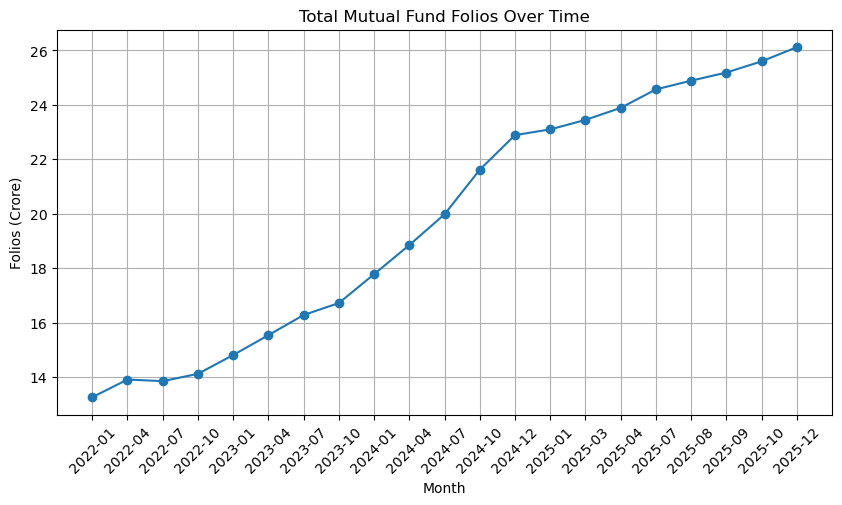

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ind_df['month'], ind_df['total_folios_crore'], marker='o')
plt.xticks(rotation=45)
plt.title("Total Mutual Fund Folios Over Time")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True)
plt.show()

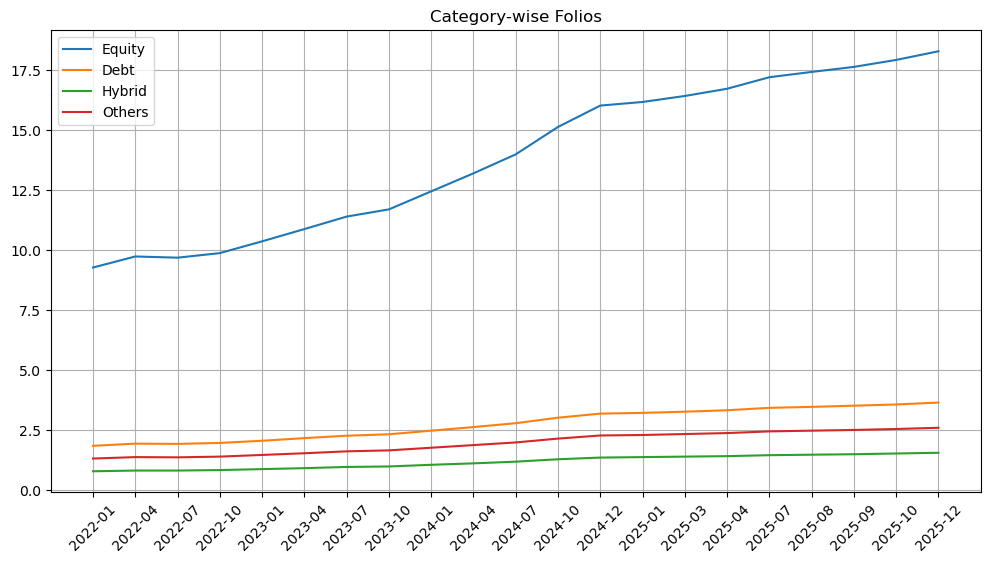

In [10]:
plt.figure(figsize=(12,6))

plt.plot(ind_df['month'], ind_df['equity_folios_crore'], label='Equity')
plt.plot(ind_df['month'], ind_df['debt_folios_crore'], label='Debt')
plt.plot(ind_df['month'], ind_df['hybrid_folios_crore'], label='Hybrid')
plt.plot(ind_df['month'], ind_df['others_folios_crore'], label='Others')

plt.xticks(rotation=45)
plt.legend()
plt.title("Category-wise Folios")
plt.grid(True)
plt.show()

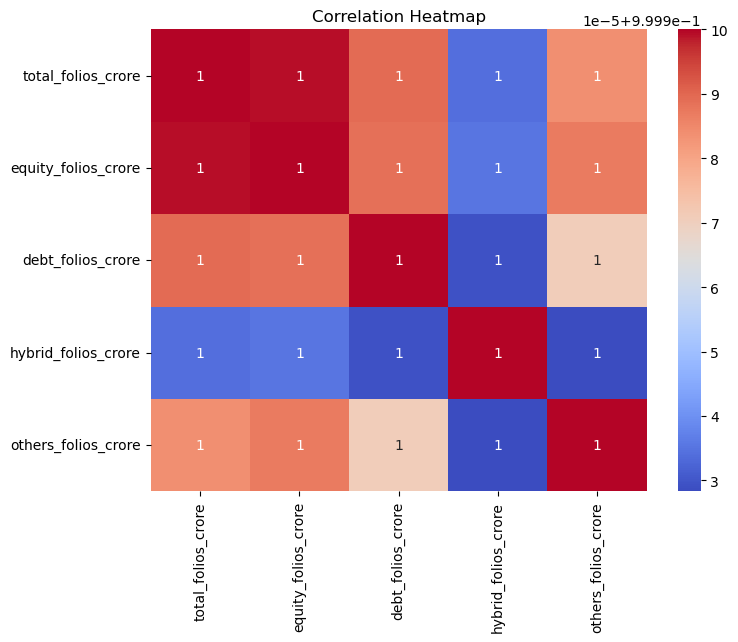

In [11]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    ind_df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

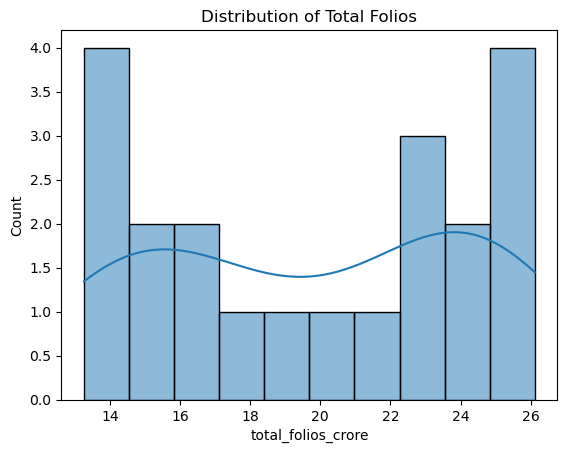

In [12]:
sns.histplot(ind_df['total_folios_crore'], bins=10, kde=True)
plt.title("Distribution of Total Folios")
plt.show()

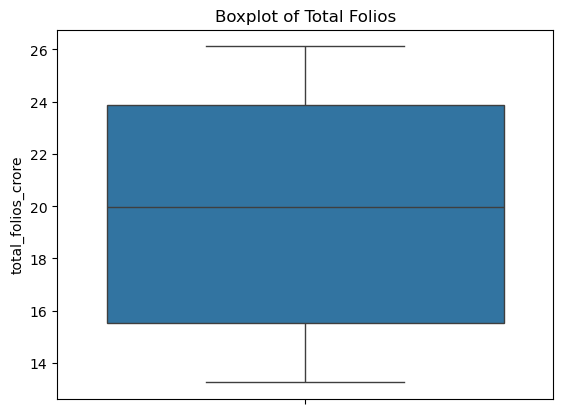

In [13]:
sns.boxplot(y=ind_df['total_folios_crore'])
plt.title("Boxplot of Total Folios")
plt.show()

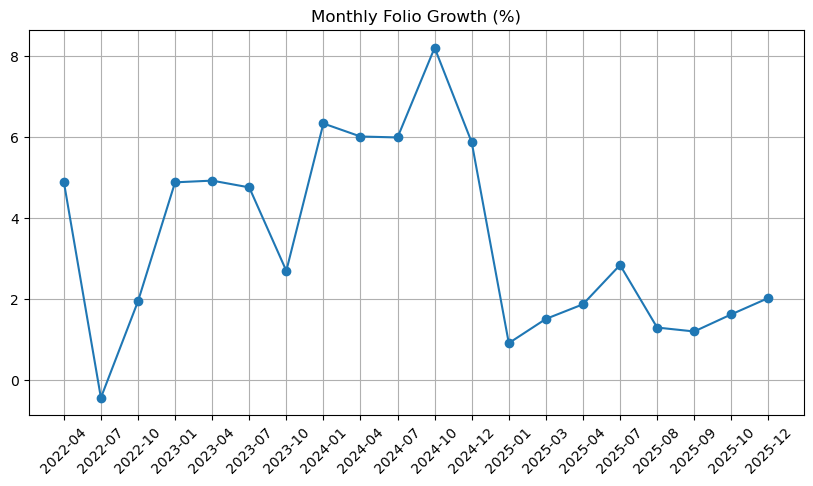

In [14]:
ind_df['growth_pct'] = ind_df['total_folios_crore'].pct_change()*100

plt.figure(figsize=(10,5))
plt.plot(ind_df['month'], ind_df['growth_pct'], marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Folio Growth (%)")
plt.grid(True)
plt.show()